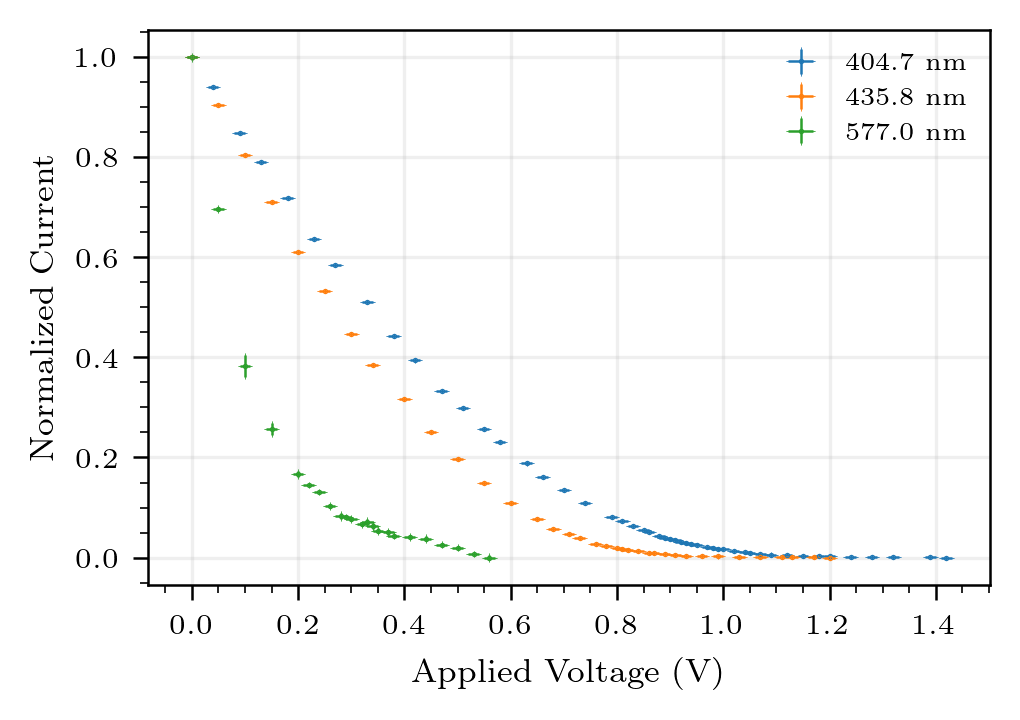

In [40]:
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import UnivariateSpline
from scipy.optimize import brentq
with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    from scipy.odr import ODR, Model, RealData

plt.style.use("./jlab.mplstyle")

k        = 5
smoothing = 10000000
c        = 299792458   # m/s
wave_unc = 2           # nm
v_unc    = 0.01        # V
e        = 1.602e-19   # C

wavelengths = np.array([404.7, 435.8, 577.0])
wave = '577.0'
colors      = plt.rcParams["axes.prop_cycle"].by_key()["color"]
wl_colors   = {wl: colors[i] for i, wl in enumerate(wavelengths)}
frequencies = c / (wavelengths * 1e-9)
freq_unc    = (c / (wavelengths * 1e-9)**2) * wave_unc * 1e-9

def load_iv_data(wl_nm):
    if(wl_nm == 577.0):
        df = pd.read_csv(f"{wave}.csv")
    else:
        df = pd.read_csv(f"{wl_nm}.csv")
    I  = df[["I1", "I2", "I3", "I4", "I5"]].values
    return df["V"].values, I.mean(axis=1), scipy.stats.sem(I, axis=1)

datasets = {}
for wl in wavelengths:
    V, I, u = load_iv_data(wl)
    datasets[wl] = V, (I - I.min()) / (I.max()-I.min()), u / (I.max()-I.min())
    # datasets[wl] = V, I, u

fig, ax = plt.subplots(figsize=(3.5, 2.5))
for wl, (V, I, u) in datasets.items():
    ax.errorbar(V, I, yerr=u, xerr=np.ones_like(u)*v_unc, fmt="o", capsize=0.1, markersize=0.3,
                color=wl_colors[wl], label=f"{wl} nm")
ax.set_xlabel("Applied Voltage (V)")
ax.set_ylabel("Normalized Current")
ax.legend()
plt.tight_layout()
plt.grid(alpha=0.2)
plt.show()


## Spline Fitting & Bootstrap Uncertainty Estimation

### Spline Fitting

For each wavelength, a weighted smoothing spline of degree $k$ is fit to the normalised I–V data. The per-point weights are $w_i = 1/u_i$, where $u_i$ is the standard error of the mean (SEM) of the repeated current measurements. A global smoothing parameter $s$ controls the trade-off between closeness of fit and smoothness.

The stopping voltage $V_s$ is identified as the leftmost zero-crossing of the second derivative $d^2I/dV^2$ within the upper 60\% of the voltage range:

$$V_s = \min\left\{\, v \in [V_0 + 0.4\,\Delta V,\; V_\mathrm{max}] \;\middle|\; \frac{d^2 I}{dV^2}(v) = 0 \,\right\}$$

where $\Delta V = V_\mathrm{max} - V_\mathrm{min}$.

### Bootstrap Uncertainty Estimation

To propagate measurement uncertainties in both $V$ and $I$ through the non-linear spline fitting procedure, a parametric bootstrap is used. For each of $N$ trials:

$$V_i^{(b)} = V_i + \varepsilon_i^V, \qquad \varepsilon_i^V \sim \mathcal{N}(0,\, \sigma_V)$$

$$I_i^{(b)} = I_i + \varepsilon_i^I, \qquad \varepsilon_i^I \sim \mathcal{N}(0,\, u_i)$$

where $\sigma_V$ is the voltage instrument resolution. The resampled data are re-sorted by voltage, a new spline is fit, and $V_s^{(b)}$ is extracted. The reported stopping voltage and uncertainty are then

$$\bar{V}_s = \frac{1}{N}\sum_{b=1}^{N} V_s^{(b)}, \qquad \sigma_{V_s} = \sqrt{\frac{1}{N}\sum_{b=1}^{N}\left(V_s^{(b)} - \bar{V}_s\right)^2}$$

### What is a Spline?

A **spline** $S(V)$ of degree $k$ is a piecewise polynomial: the voltage domain $[V_\min, V_\max]$ is divided at a sequence of internal points $t_1 < t_2 < \cdots < t_m$ called **knots**, and on each interval $[t_j, t_{j+1}]$ the function $S$ is a polynomial of degree at most $k$. At every knot, $S$ is continuous and has continuous derivatives up to order $k-1$.

Here a *smoothing* spline is used: the knots and coefficients are chosen to minimise the number of knots while keeping the weighted residual sum below the smoothing threshold $s$,

$$\sum_{i} w_i^2 \left(I_i - S(V_i)\right)^2 \leq s, \qquad w_i = \frac{1}{u_i}$$

A larger $s$ produces a smoother (fewer-knot) spline at the cost of a worse fit to the data.


In [41]:
def fit_spline(V, I, u, k_deg=None):
    """Fit a weighted UnivariateSpline and return the spline, its 2nd derivative, and a fine voltage grid."""
    k_use  = k_deg if k_deg is not None else k
    w      = np.where(u > 0, 1 / u, 1.0)
    us     = UnivariateSpline(V, I, w=w, k=k_use, s=smoothing)
    d2     = us.derivative().derivative()
    v_fine = np.linspace(V[0], V[-1], 500)
    return us, d2, v_fine

def find_vstop(d2, V, frac=0.4):
    """Find the leftmost zero-crossing of d2 in the upper (1-frac) fraction of the voltage range."""
    v_lo     = V[0] + frac * (V[-1] - V[0])
    v_search = np.linspace(v_lo, V[-1], 2000)
    idx      = np.where(np.diff(np.sign(d2(v_search))))[0]
    return brentq(d2, v_search[idx[0]], v_search[idx[0] + 1]) if idx.size > 0 else np.nan

def bootstrap_vstop(V, I, u, N=100, k_deg=None):
    """
    Estimate V_stop uncertainty by resampling data points with Gaussian noise.
    V noise: std = v_unc (voltage instrument uncertainty)
    I noise: std = u (per-point current SEM)
    Returns (mean, std) of V_stop across N trials, plus list of precomputed sample tuples.
    """
    samples = []
    vstops  = []
    for _ in range(N):
        V_boot = V + np.random.normal(0, v_unc, size=V.shape)
        I_boot = I + np.random.normal(0, u,     size=I.shape)
        order  = np.argsort(V_boot)
        V_b, I_b, u_b = V_boot[order], I_boot[order], u[order]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                us_b, d2_b, v_b = fit_spline(V_b, I_b, u_b, k_deg=k_deg)
            vstop_b = find_vstop(d2_b, V_b)
            if np.isfinite(vstop_b):
                samples.append((v_b, us_b(v_b), d2_b(v_b), vstop_b))
                vstops.append(vstop_b)
        except Exception:
            pass
    return np.mean(vstops), np.std(vstops), samples


In [42]:
N = 1000

# --- Primary bootstrap: k=4 ---
boot_results = {}
boot_samples = {}
V_stops      = []
V_stops_unc  = []

for wl, (V, I, u) in datasets.items():
    mean, unc, samples = bootstrap_vstop(V, I, u, N=N, k_deg=4)
    boot_results[wl] = (mean, unc)
    boot_samples[wl] = samples
    V_stops.append(mean)
    V_stops_unc.append(unc)

V_stops     = np.array(V_stops)
V_stops_unc = np.array(V_stops_unc)

# --- Comparison bootstrap: k=5 ---
boot_results_k5 = {}

for wl, (V, I, u) in datasets.items():
    mean, unc, _ = bootstrap_vstop(V, I, u, N=N, k_deg=5)
    boot_results_k5[wl] = (mean, unc)

# --- Comparison table ---
print(f"{'λ (nm)':>8}  {'k=4: V_s (V)':>18}  {'k=5: V_s (V)':>18}  {'Δ (V)':>8}")
print("-" * 60)
for wl in wavelengths:
    m4, u4 = boot_results[wl]
    m5, u5 = boot_results_k5[wl]
    print(f"{wl:>8.1f}  {m4:.4f} ± {u4:.4f}   {m5:.4f} ± {u5:.4f}   {m5-m4:+.4f}")


  λ (nm)        k=4: V_s (V)        k=5: V_s (V)     Δ (V)
------------------------------------------------------------
   404.7  1.2570 ± 0.0088   1.2608 ± 0.0125   +0.0038
   435.8  1.0250 ± 0.0180   1.0314 ± 0.0203   +0.0064
   577.0  0.4017 ± 0.0249   0.3975 ± 0.0485   -0.0041


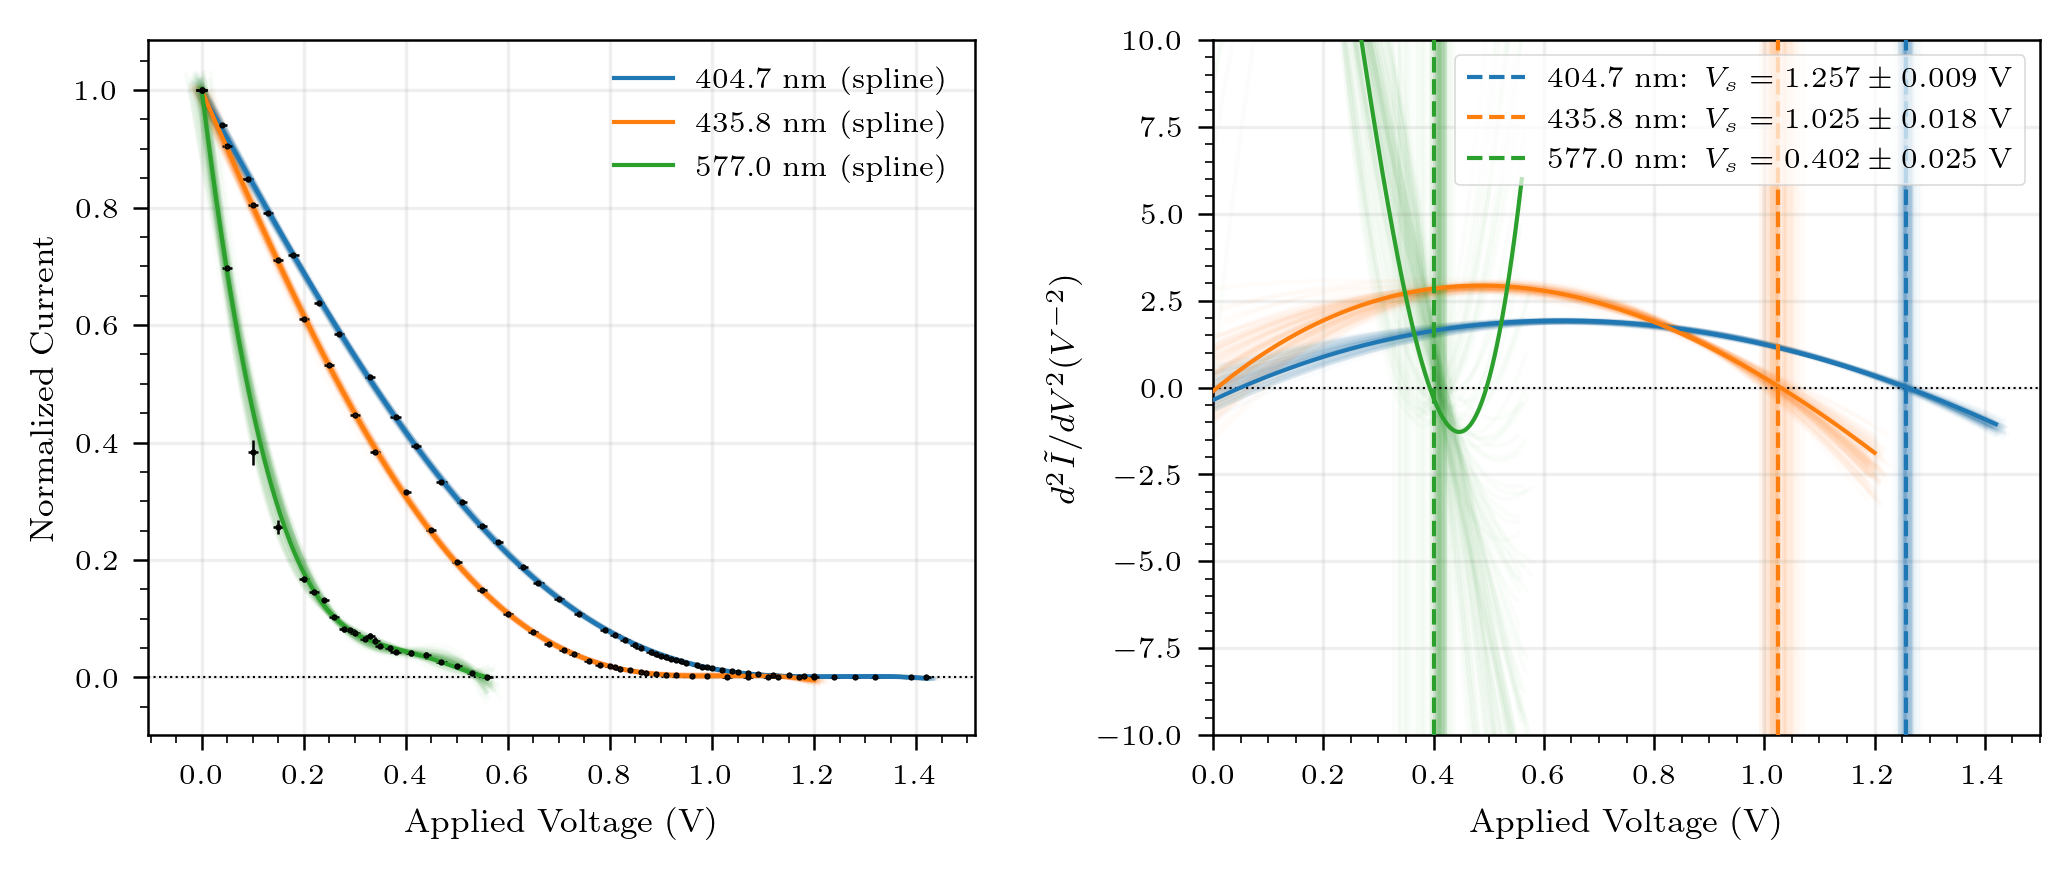

In [43]:
# --- settings ---
n_show      = 100
lw_main     = 1.0
lw_resample = 1.0
alpha_iv    = 0.02
alpha_d2    = 0.02
alpha_vstop = 0.02

fig, (ax_iv, ax_d2) = plt.subplots(1, 2, figsize=(7, 3))

for wl, (V, I, u) in datasets.items():
    color = wl_colors[wl]
    us_main, d2_main, v_fine = fit_spline(V, I, u)
    boot_mean, boot_unc = boot_results[wl]
    samples = boot_samples[wl]

    # raw data
    ax_iv.errorbar(V, I, yerr=u, xerr=v_unc, fmt="o", markersize=0.5, capsize=0, color="black", zorder=3)
    # main spline
    ax_iv.plot(v_fine, us_main(v_fine), color=color, linewidth=lw_main, label=f"{wl} nm (spline)", zorder=3)
    # main d²
    ax_d2.plot(v_fine, d2_main(v_fine), color=color, linewidth=lw_main, zorder=3)
    # mean V_stop line
    ax_d2.axvline(boot_mean, color=color, linewidth=lw_main, linestyle="--", zorder=3,
                  label=rf"{wl:.1f} nm: $V_s = {boot_mean:.3f} \pm {boot_unc:.3f}$ V")
    # resampled trajectories (k=4 only, from precomputed boot_samples)
    for v_b, spline_vals, d2_vals, vstop_b in samples[:n_show]:
        ax_iv.plot(v_b, spline_vals, color=color, linewidth=lw_resample, alpha=alpha_iv)
        ax_d2.plot(v_b, d2_vals,    color=color, linewidth=lw_resample, alpha=alpha_d2)
        ax_d2.axvline(vstop_b,      color=color, linewidth=lw_resample, alpha=alpha_vstop)

#horizontal line for ax_iv
ax_iv.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax_iv.grid(alpha=0.2)
ax_iv.set_xlabel("Applied Voltage (V)")
ax_iv.set_ylabel("Normalized Current")
ax_iv.legend(fontsize=7)

ax_d2.grid(alpha=0.2)
ax_d2.axhline(0, color="k", linewidth=0.5, linestyle=":")
ax_d2.set_xlim(0.0, 1.5)
ax_d2.set_ylim(-10, 10)
ax_d2.set_xlabel("Applied Voltage (V)")
ax_d2.set_ylabel(r"$d^2 \tilde{I}/dV^2 (V^{-2})$")
ax_d2.legend(fontsize=7, framealpha=0.7, frameon=True)

fig.tight_layout()
plt.show()

k=4:  h = (6.183 ± 0.235) × 10⁻³⁴ J·s
k=5:  h = (6.310 ± 0.284) × 10⁻³⁴ J·s
true: h =  6.626 × 10⁻³⁴ J·s

φ_A (k=4) = (1.611 ± 0.101) eV
φ_A (k=5) = (1.664 ± 0.125) eV


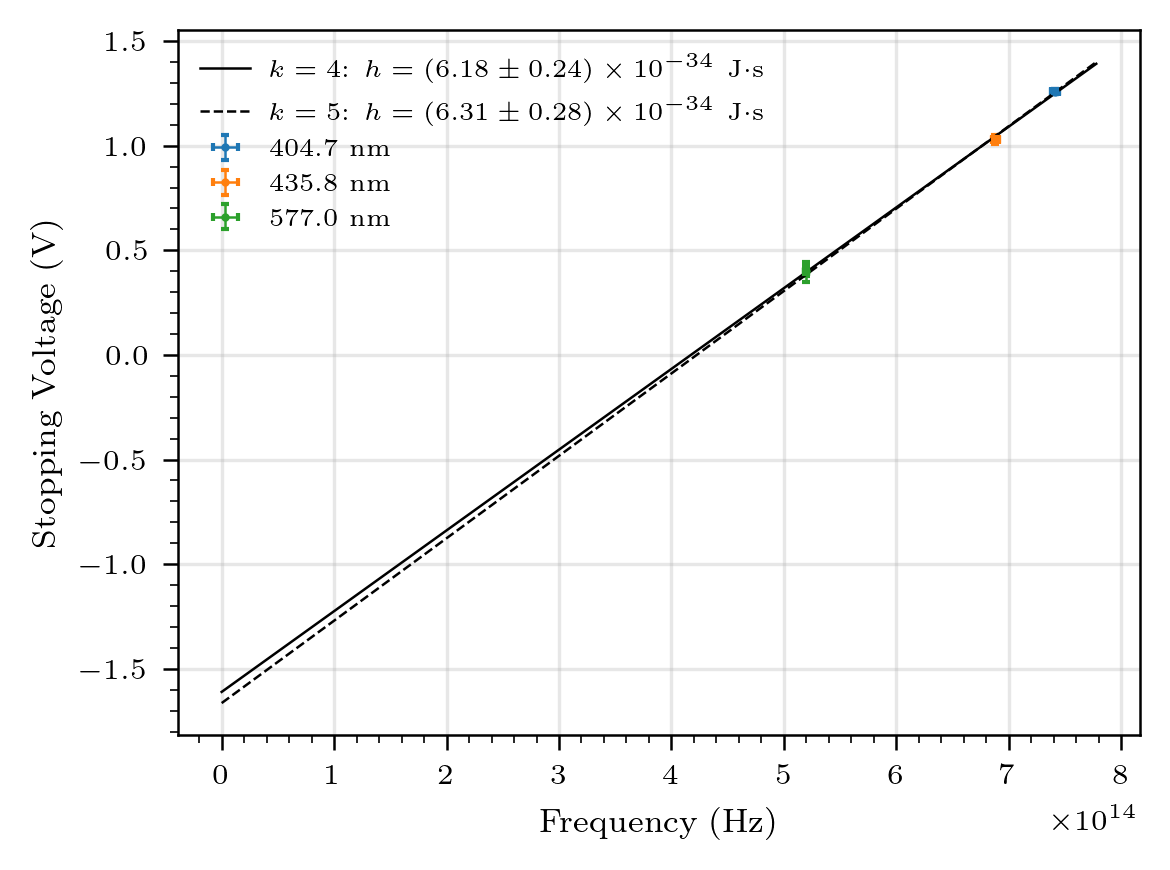

In [44]:
markersize = 1
capsize = 1

def linear_odr(beta, x):
    return beta[0] * x + beta[1]

def run_odr(V_s, V_s_unc):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        data   = RealData(frequencies, V_s, sx=freq_unc, sy=V_s_unc)
        result = ODR(data, Model(linear_odr), beta0=[3.8e-15, -1.0]).run()
    return result.beta, result.sd_beta

# k=4 ODR
V_stops_k5     = np.array([boot_results_k5[wl][0] for wl in wavelengths])
V_stops_unc_k5 = np.array([boot_results_k5[wl][1] for wl in wavelengths])

(m4, b4), (m4_err, b4_err) = run_odr(V_stops,    V_stops_unc)
(m5, b5), (m5_err, b5_err) = run_odr(V_stops_k5, V_stops_unc_k5)

h4,   h4_err   = e * m4,  e * m4_err
h5,   h5_err   = e * m5,  e * m5_err
phi4, phi4_err = -b4, b4_err
phi5, phi5_err = -b5, b5_err

print(f"k=4:  h = ({h4/1e-34:.3f} ± {h4_err/1e-34:.3f}) × 10⁻³⁴ J·s")
print(f"k=5:  h = ({h5/1e-34:.3f} ± {h5_err/1e-34:.3f}) × 10⁻³⁴ J·s")
print(f"true: h =  6.626 × 10⁻³⁴ J·s")
print()
print(f"φ_A (k=4) = ({phi4:.3f} ± {phi4_err:.3f}) eV")
print(f"φ_A (k=5) = ({phi5:.3f} ± {phi5_err:.3f}) eV")

f_fit = np.linspace(0, frequencies.max() * 1.05, 200)

fig, ax = plt.subplots(figsize=(4, 3))

for wl, f, f_u in zip(wavelengths, frequencies, freq_unc):
    m4_i, u4_i = boot_results[wl]
    m5_i, u5_i = boot_results_k5[wl]
    color = wl_colors[wl]
    ax.errorbar(f, m4_i, yerr=u4_i, xerr=f_u, fmt="o",  markersize=markersize, capsize=capsize, color=color, label=f"{wl} nm")
    ax.errorbar(f, m5_i, yerr=u5_i, xerr=f_u, fmt="s",  markersize=markersize, capsize=capsize, color=color)

ax.plot(f_fit, m4 * f_fit + b4,
        color="k", linestyle="-",
        label=rf"$k=4$: $h = ({h4/1e-34:.2f} \pm {h4_err/1e-34:.2f}) \times 10^{{-34}}$ J·s")
ax.plot(f_fit, m5 * f_fit + b5,
        color="k", linestyle="--",
        label=rf"$k=5$: $h = ({h5/1e-34:.2f} \pm {h5_err/1e-34:.2f}) \times 10^{{-34}}$ J·s")

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Stopping Voltage (V)")
ax.legend(fontsize=6)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
